In [1]:
import torch
from src.dataset import get_datasets
from src.utils import get_dataloaders_for
from src.io import save_model_weights, load_model_weights
from src.utils import get_device
from src.models.fpsnet import FPSNet, train_model, test_model

In [2]:
device = get_device()

In [3]:
N_ATT = 35 # this is an upper bound on the number of craters

train_dataset, test_dataset = get_datasets("fpsnet_dataset", n_att=N_ATT, dim=600)
train_dataloader, test_dataloader = get_dataloaders_for(train_dataset, test_dataset, batch_size=2)

In [4]:
print("Train Dataset:", train_dataset)
print("Test Dataset:", test_dataset)

Train Dataset: 81 images
Test Dataset: 20 images


In [5]:
retina_net_state = load_model_weights("saved_weights", "crater_retinanet_weights.pth")


Model weights successfully loaded from: saved_weights\crater_retinanet_weights.pth


In [6]:
model = FPSNet(n_att=N_ATT, n_stuff=0, c_att=50, retina_net_state=retina_net_state, device=device).to(device) # instantiating the model
model.eval()

FPSNet(
  (retina_net): RetinaNet(
    (backbone): BackboneWithFPN(
      (body): IntermediateLayerGetter(
        (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
        (layer1): Sequential(
          (0): Bottleneck(
            (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
            (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
            (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
            (bn3): BatchNorm2d(256, eps=1e-05, momentu

In [7]:
EPOCHS = 1
train_model(model, device, train_dataloader, N_ATT, EPOCHS)

Starting training on device: cuda
Epoch 1/1, Batch 10
  Total Loss: 3.9055 | PCE: 3.5096 | CLS: 0.4310 | BOX: 0.3607
Epoch 1/1, Batch 20
  Total Loss: 3.5357 | PCE: 3.2491 | CLS: 0.2931 | BOX: 0.2802
Epoch 1/1, Batch 30
  Total Loss: 3.4789 | PCE: 3.1454 | CLS: 0.3471 | BOX: 0.3199
Epoch 1/1, Batch 40
  Total Loss: 2.8928 | PCE: 2.5836 | CLS: 0.3154 | BOX: 0.3030
--- Epoch 1 finished. Avg Loss: 3.6102 ---
Training complete


torch.Size([3, 600, 600])


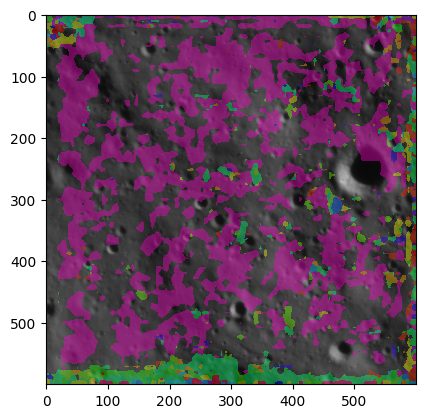

In [8]:
from src.utils import to_binary_masks
from src.dataset import LunarCraterDataset

output = None
test_image, test_mask = train_dataset[0]
print(test_image.shape)
with torch.inference_mode():
    output = model(test_image.unsqueeze(0).to(device))
    binary_masks = to_binary_masks(output["values"])
    LunarCraterDataset.view_image(test_image, binary_masks[0][:N_ATT])

In [9]:
output["labels"][0].shape, output["scores"][0].shape

(torch.Size([35]), torch.Size([35]))

In [10]:
output["scores"][0]

tensor([0.1957, 0.2181, 0.2624, 0.2318, 0.1725, 0.2201, 0.1933, 0.2910, 0.2426,
        0.1802, 0.1743, 0.1766, 0.1832, 0.6003, 0.1900, 0.1805, 0.2395, 0.2492,
        0.1700, 0.4970, 0.1783, 0.1743, 0.2821, 0.2349, 0.1890, 0.2066, 0.1772,
        0.1898, 0.3647, 0.1921, 0.2239, 0.2692, 0.1834, 0.1939, 0.1757],
       device='cuda:0')

In [11]:
train_dataset.dataset_path

'fpsnet_dataset\\train'

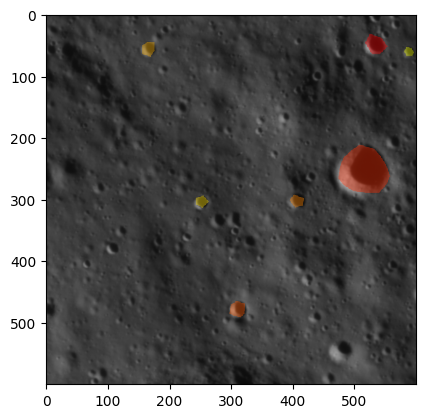

In [12]:
train_dataset.view(0)

In [14]:
metrics = test_model(model, device, test_dataloader, n_att=N_ATT, crater_class_id=1)
print(f"{metrics[0]["name"]}: {metrics[0]["value"]:.4f}")

Panoptic Quality: 0.0000


In [ ]:
# save_model_weights(model, "saved_weights", "crater_fpsnet_weights.pth")